In [61]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')

base_path = '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/train' 
classes = os.listdir(base_path)
print(classes)

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [62]:
# 1. Check Class Distribution
stats = []
for c in classes:
    count = len(os.listdir(os.path.join(base_path, c)))
    stats.append({'Class': c, 'Count': count})

df_stats = pd.DataFrame(stats)
print(df_stats)


       Class  Count
0   mountain   2261
1     street   2144
2  buildings   1972
3        sea   2047
4     forest   2044
5    glacier   2164


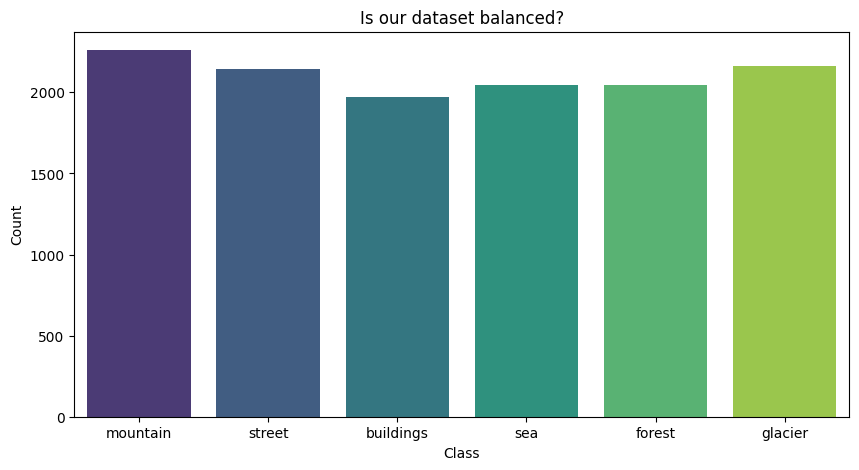

In [63]:
# 2. Visualize the Balance
plt.figure(figsize=(10,5))
sns.barplot(x='Class', y='Count', data=df_stats, palette='viridis')
plt.title('Is our dataset balanced?')
plt.show()

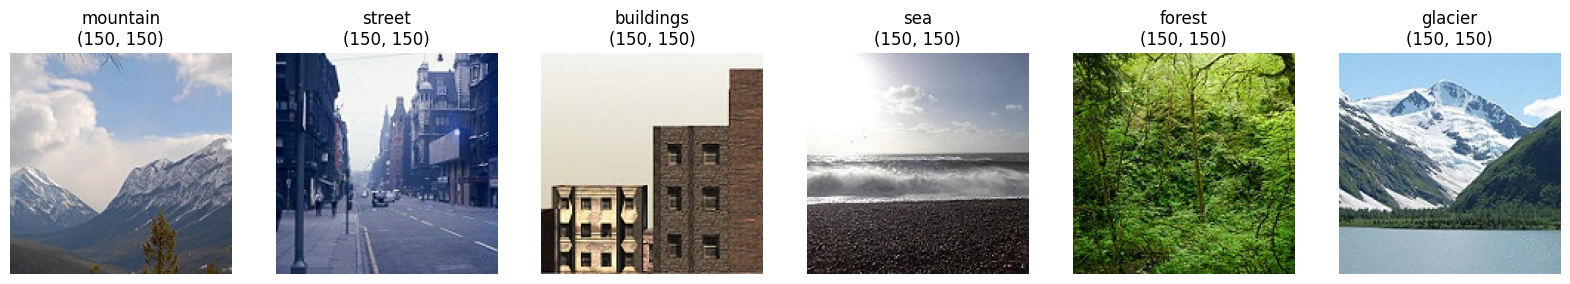

In [64]:
fig, axes = plt.subplots(1, 6, figsize=(20, 10))
for i, c in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(base_path, c)))
    img_path = os.path.join(base_path, c, img_name)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{c}\n{img.size}")
    axes[i].axis('off')
plt.show()

# [](http://)Intel Image Classification pretrained Model CNN

In [78]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize (0-255 to 0-1)
    horizontal_flip=True,     
    rotation_range=15,        
    brightness_range=[0.8,1.2] 
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Loading the Data
train_loader = train_datagen.flow_from_directory(
    '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/train',
    target_size=(224, 224),   # Resize
    batch_size=32,
    class_mode='categorical'
)

val_loader = val_datagen.flow_from_directory(
    '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/val', 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

test_loader = test_datagen.flow_from_directory(
    '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False      
)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [79]:
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(224,224, 3)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    # keras.layers.Dropout(0.2),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    # keras.layers.Dropout(0.3),

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)

save_point = keras.callbacks.ModelCheckpoint(
    'intel.keras', save_best_only=True, verbose=1
)

history = model.fit(
    train_loader,
    epochs=100,
    validation_data=val_loader,
    callbacks=[early_stopping, save_point],
    verbose=1
)


Epoch 1/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.5181 - loss: 1.2708
Epoch 1: val_loss improved from inf to 0.89868, saving model to intel.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 165s 410ms/step - accuracy: 0.5183 - loss: 1.2702 - val_accuracy: 0.6641 - val_loss: 0.8987
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7191 - loss: 0.7940
Epoch 2: val_loss improved from 0.89868 to 0.55825, saving model to intel.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 159s 401ms/step - accuracy: 0.7191 - loss: 0.7939 - val_accuracy: 0.8024 - val_loss: 0.5582
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7686 - loss: 0.6466
Epoch 3: val_loss did not improve from 0.55825
395/395 ━━━━━━━━━━━━━━━━━━━━ 158s 401ms/step - accuracy: 0.7686 - loss: 0.6466 - val_accuracy: 0.7896 - val_loss: 0.6597
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7881 - loss: 0.5820
Epoch 4: val_loss improved from 0.55825 to 0.50301, saving model to intel.kera

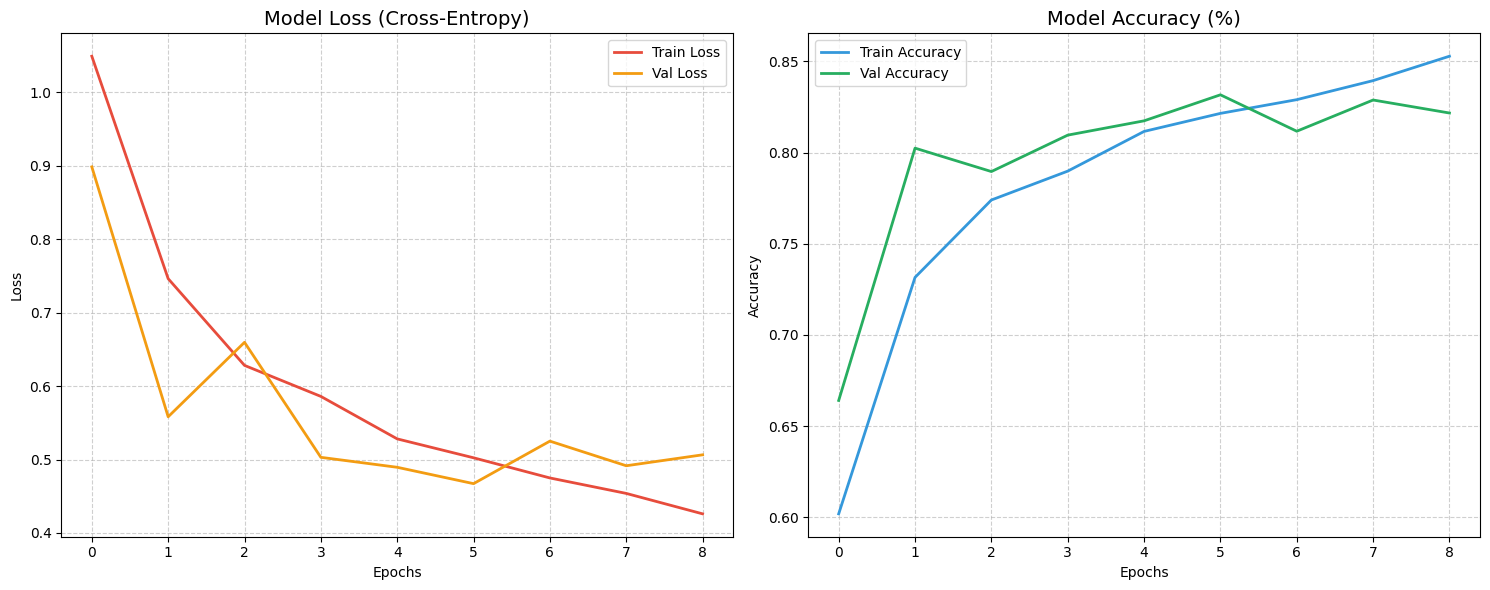

In [81]:
hist = pd.DataFrame(history.history)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Train Loss', color='#e74c3c', linewidth=2)
plt.plot(hist['val_loss'], label='Val Loss', color='#f39c12', linewidth=2)
plt.title('Model Loss (Cross-Entropy)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
plt.plot(hist['val_accuracy'], label='Val Accuracy', color='#27ae60', linewidth=2)
plt.title('Model Accuracy (%)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [82]:
model = keras.models.load_model('intel.keras')

# Evaluate on test set
loss, accuracy = model.evaluate(test_loader)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.8457 - loss: 0.4378
Test Loss: 0.4642
Test Accuracy: 0.8350


In [83]:
import numpy as np
y_test = test_loader.classes 
predictions = model.predict(test_loader)
y_pred = np.argmax(predictions, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step


In [84]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

# Overall accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Precision, Recall, F1
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\nPrecision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")


TEST SET EVALUATION
Accuracy: 0.8350 (83.50%)

Precision (Macro): 0.8370
Precision (Weighted): 0.8364
Recall (Macro): 0.8378
Recall (Weighted): 0.8350
F1-Score (Macro): 0.8357
F1-Score (Weighted): 0.8340


In [85]:
class_names = list(test_loader.class_indices.keys())

print(f"\n{'='*50}")
print("CLASSIFICATION REPORT")
print(f"{'='*50}")

print(classification_report(y_test, y_pred, target_names=class_names))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   buildings       0.79      0.84      0.81       437
      forest       0.95      0.96      0.95       474
     glacier       0.81      0.79      0.80       553
    mountain       0.84      0.70      0.76       525
         sea       0.78      0.88      0.83       510
      street       0.86      0.85      0.85       501

    accuracy                           0.83      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.83      0.83      3000



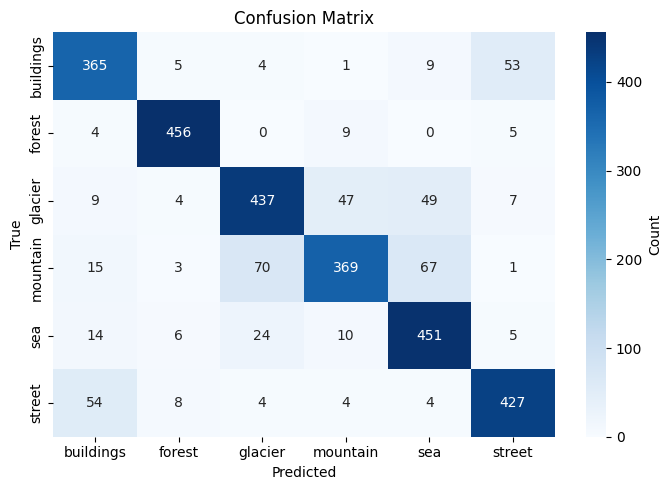


Confusion Matrix - Interpretation:
  Diagonal: Correct predictions
  Off-diagonal: Misclassifications


In [86]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix - Interpretation:")
print(f"  Diagonal: Correct predictions")
print(f"  Off-diagonal: Misclassifications")

# [](http://)Intel Image Classification pretrained Model Using EfficientNetB0

In [87]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

train_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3, 
    horizontal_flip=True,
    fill_mode='reflect' 
)

val_datagen2 = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen2 = ImageDataGenerator(preprocessing_function=preprocess_input)

train_loader2 = train_datagen2.flow_from_directory(
    '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/train',
    target_size=(224, 224),   # Resize
    batch_size=32,
    class_mode='categorical'
)

val_loader2 = val_datagen2.flow_from_directory(
    '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/val', 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

test_loader2 = test_datagen2.flow_from_directory(
    '/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False      
)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [88]:
base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(6, activation='softmax')
])

model2.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

lr_reducer2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
early_stopping2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Phase 1: Warming up the top layers...")
model2.fit(train_loader2, epochs=5, validation_data=val_loader2, callbacks=[lr_reducer2, early_stopping2])

base_model.trainable = True
for layer in base_model.layers[:-20]: 
    layer.trainable = False

model2.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("\nPhase 2: Fine-Tuning for maximum accuracy...")
history2 = model2.fit(train_loader2, epochs=20, validation_data=val_loader2, callbacks=[lr_reducer2, early_stopping2])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Phase 1: Warming up the top layers...
Epoch 1/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 197s 443ms/step - accuracy: 0.7335 - loss: 0.7851 - val_accuracy: 0.9030 - val_loss: 0.2656 - learning_rate: 0.0010
Epoch 2/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 152s 385ms/step - accuracy: 0.8582 - loss: 0.3958 - val_accuracy: 0.9001 - val_loss: 0.2774 - learning_rate: 0.0010
Epoch 3/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 154s 389ms/step - accuracy: 0.8738 - loss: 0.3534 - val_accuracy: 0.9116 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 4/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 149s 378ms/step - accuracy: 0.8821 - loss: 0.3286 - val_accuracy: 0.9023 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 5/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 151s 383ms/step - accuracy: 0.8828 - loss: 0.3216 - val_accuracy: 0.9201 - val_loss: 0.2293 - learning_rate: 0.0010

Phase 2: Fine-Tuning for maximum accuracy...
Epoch 1/20


2026-03-26 10:36:46.413937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 10:36:46.620949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


141/395 ━━━━━━━━━━━━━━━━━━━━ 1:34 373ms/step - accuracy: 0.8044 - loss: 0.5735

2026-03-26 10:37:51.085579: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 10:37:51.294787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


395/395 ━━━━━━━━━━━━━━━━━━━━ 197s 439ms/step - accuracy: 0.8099 - loss: 0.5402 - val_accuracy: 0.8944 - val_loss: 0.2857 - learning_rate: 1.0000e-05
Epoch 2/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 151s 383ms/step - accuracy: 0.8475 - loss: 0.4239 - val_accuracy: 0.9051 - val_loss: 0.2611 - learning_rate: 1.0000e-05
Epoch 3/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 151s 382ms/step - accuracy: 0.8605 - loss: 0.3885 - val_accuracy: 0.9101 - val_loss: 0.2476 - learning_rate: 1.0000e-05
Epoch 4/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 152s 384ms/step - accuracy: 0.8670 - loss: 0.3730 - val_accuracy: 0.9158 - val_loss: 0.2401 - learning_rate: 1.0000e-05
Epoch 5/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 151s 383ms/step - accuracy: 0.8802 - loss: 0.3347 - val_accuracy: 0.9130 - val_loss: 0.2342 - learning_rate: 1.0000e-05
Epoch 6/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 153s 387ms/step - accuracy: 0.8787 - loss: 0.3502 - val_accuracy: 0.9194 - val_loss: 0.2318 - learning_rate: 1.0000e-05
Epoch 7/20
395/395 ━━━━━━━━━━━━━━━━━━━━ 149s 378ms/

In [89]:
model2.save('final_intel_model.keras')

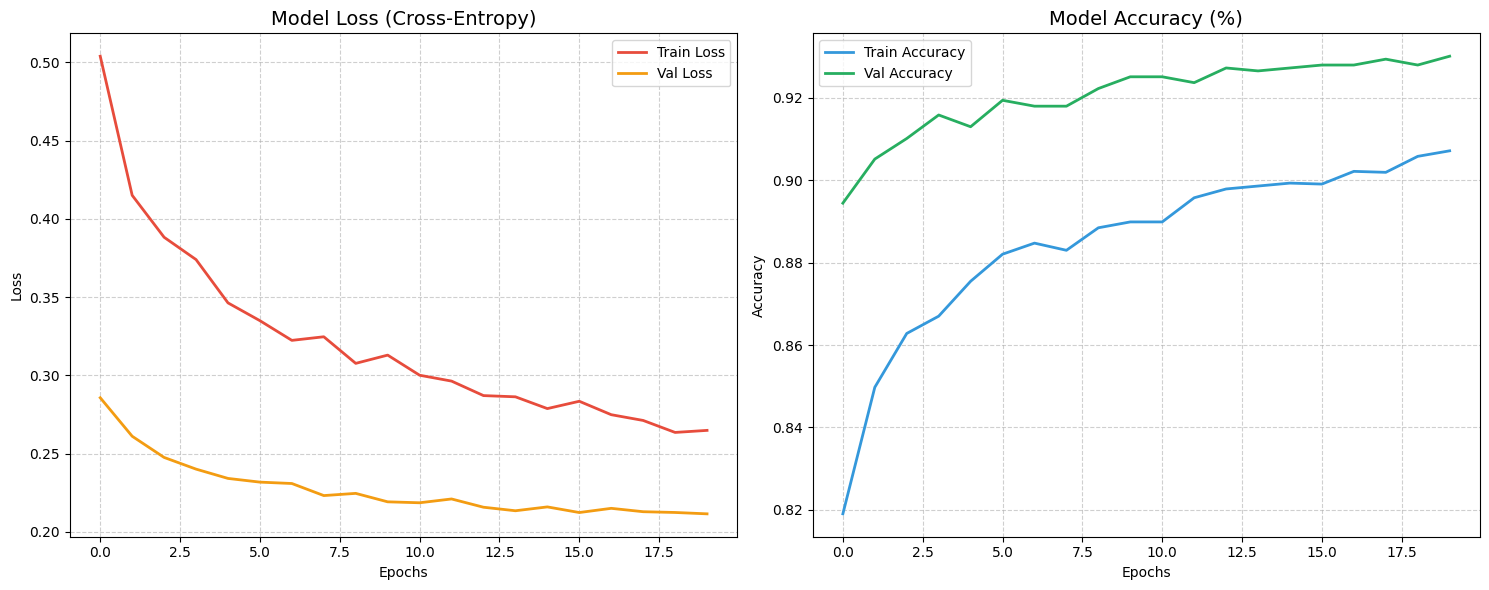

In [90]:
hist2 = pd.DataFrame(history2.history)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(hist2['loss'], label='Train Loss', color='#e74c3c', linewidth=2)
plt.plot(hist2['val_loss'], label='Val Loss', color='#f39c12', linewidth=2)
plt.title('Model Loss (Cross-Entropy)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist2['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
plt.plot(hist2['val_accuracy'], label='Val Accuracy', color='#27ae60', linewidth=2)
plt.title('Model Accuracy (%)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [91]:
pre_model = keras.models.load_model('final_intel_model.keras')

# Evaluate on test set
loss, accuracy = pre_model.evaluate(test_loader2)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.9323 - loss: 0.2087
Test Loss: 0.2148
Test Accuracy: 0.9243


In [92]:
import numpy as np
y_test2 = test_loader2.classes 
predictions2 = pre_model.predict(test_loader2)
y_pred2 = np.argmax(predictions2, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step


In [93]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

# Overall accuracy
test_accuracy = np.mean(y_pred2 == y_test2)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Precision, Recall, F1
precision_macro = precision_score(y_test2, y_pred2, average='macro')
precision_weighted = precision_score(y_test2, y_pred2, average='weighted')
recall_macro = recall_score(y_test2, y_pred2, average='macro')
recall_weighted = recall_score(y_test2, y_pred2, average='weighted')
f1_macro = f1_score(y_test2, y_pred2, average='macro')
f1_weighted = f1_score(y_test2, y_pred2, average='weighted')

print(f"\nPrecision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")


TEST SET EVALUATION
Accuracy: 0.9243 (92.43%)

Precision (Macro): 0.9268
Precision (Weighted): 0.9247
Recall (Macro): 0.9263
Recall (Weighted): 0.9243
F1-Score (Macro): 0.9262
F1-Score (Weighted): 0.9242


In [94]:
class_names = list(test_loader.class_indices.keys())

print(f"\n{'='*50}")
print("CLASSIFICATION REPORT")
print(f"{'='*50}")

print(classification_report(y_test2, y_pred2, target_names=class_names))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   buildings       0.93      0.94      0.93       437
      forest       1.00      0.99      0.99       474
     glacier       0.85      0.89      0.87       553
    mountain       0.90      0.83      0.87       525
         sea       0.94      0.97      0.96       510
      street       0.94      0.94      0.94       501

    accuracy                           0.92      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.92      0.92      0.92      3000



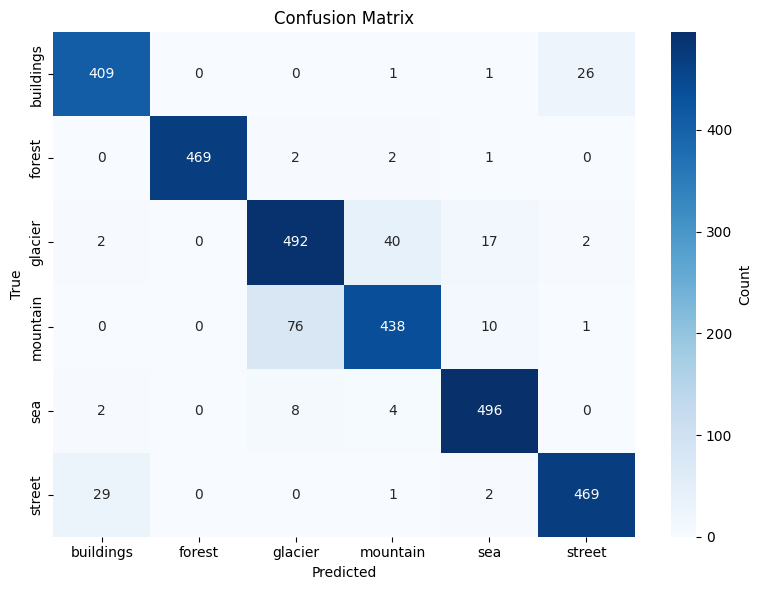


Confusion Matrix - Interpretation:
  Diagonal: Correct predictions
  Off-diagonal: Misclassifications


In [95]:
cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix - Interpretation:")
print(f"  Diagonal: Correct predictions")
print(f"  Off-diagonal: Misclassifications")